# Bonus Task — Cost-Aware Inverse Material Design
## EXCAVATE | MatRisk AI | COMPOSIT, IIT Kharagpur

**Objective:**  
Given a performance target (MQI) and a cost budget, identify the best real materials from DS1  
by combining material science signals (DS1) with real element market prices (DS5).

**Key idea — Inverse Design:**  
Instead of predicting MQI from properties (forward), we *search* the materials space  
for candidates that maximise MQI per unit cost — a classic materials informatics problem.

**Datasets used:**
- `DS1_with_MQI.csv` — 5,500 materials with computed MQI (from Task 1)  
- `DS5_element_prices_monthly.csv` — monthly prices of 40 elements (2014–2024)

---

## 1. Imports & Setup

In [4]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("Libraries loaded.")

Libraries loaded.


## 2. Load Data

In [5]:
ds1 = pd.read_csv('DS1_with_MQI.csv')
ds5 = pd.read_csv('DS5_element_prices_monthly.csv')
ds5['date'] = pd.to_datetime(ds5['date'])

print(f"DS1 shape : {ds1.shape}")
print(f"DS5 shape : {ds5.shape}")
print(f"\nDS1 columns : {ds1.columns.tolist()}")
print(f"\nElements in DS5 ({ds5['element'].nunique()}): {sorted(ds5['element'].unique())}")
print(f"\nPrice history: {ds5['date'].min().date()} → {ds5['date'].max().date()}")

DS1 shape : (5500, 11)
DS5 shape : (5280, 5)

DS1 columns : ['material_id', 'formula', 'category', 'crystal_system', 'MQI', 'bulk_modulus_GPa', 'shear_modulus_GPa', 'density_g_cm3', 'melting_point_K', 'band_gap_eV', 'formation_energy_per_atom_eV']

Elements in DS5 (40): ['Ag', 'Al', 'Au', 'B', 'Bi', 'C', 'Ce', 'Co', 'Cr', 'Cu', 'Dy', 'Fe', 'Ga', 'Ge', 'Hf', 'In', 'La', 'Li', 'Mg', 'Mn', 'Mo', 'N', 'Nb', 'Nd', 'Ni', 'Pb', 'Pt', 'Re', 'Sb', 'Sc', 'Se', 'Si', 'Sn', 'Ta', 'Te', 'Ti', 'V', 'W', 'Zn', 'Zr']

Price history: 2014-01-01 → 2024-12-01


## 3. Element Price Analysis (DS5)

In [6]:
# Latest prices per element
latest_prices = ds5.sort_values('date').groupby('element')['price_usd_per_kg'].last()
print("Latest element prices (USD/kg):")
print(latest_prices.sort_values(ascending=False).round(2).to_string())

Latest element prices (USD/kg):
element
Au    57479.25
Pt    30341.35
Sc     3880.54
Re     2832.97
Hf      952.96
Ge      901.47
Ag      591.96
Dy      373.57
Ga      317.37
In      252.89
Ta      142.17
Nd       79.83
Te       56.53
Co       53.05
Mo       44.56
Nb       43.42
W        39.96
Zr       30.04
V        29.82
Li       27.33
Se       25.06
Sn       24.01
Ni       17.92
Bi       11.15
Ti       10.17
Cu        9.15
Cr        8.53
Sb        7.99
La        5.45
B         4.50
Ce        4.09
Zn        2.74
Si        2.60
Al        2.27
Mg        2.19
Pb        2.17
Mn        2.00
C         0.51
N         0.28
Fe        0.09


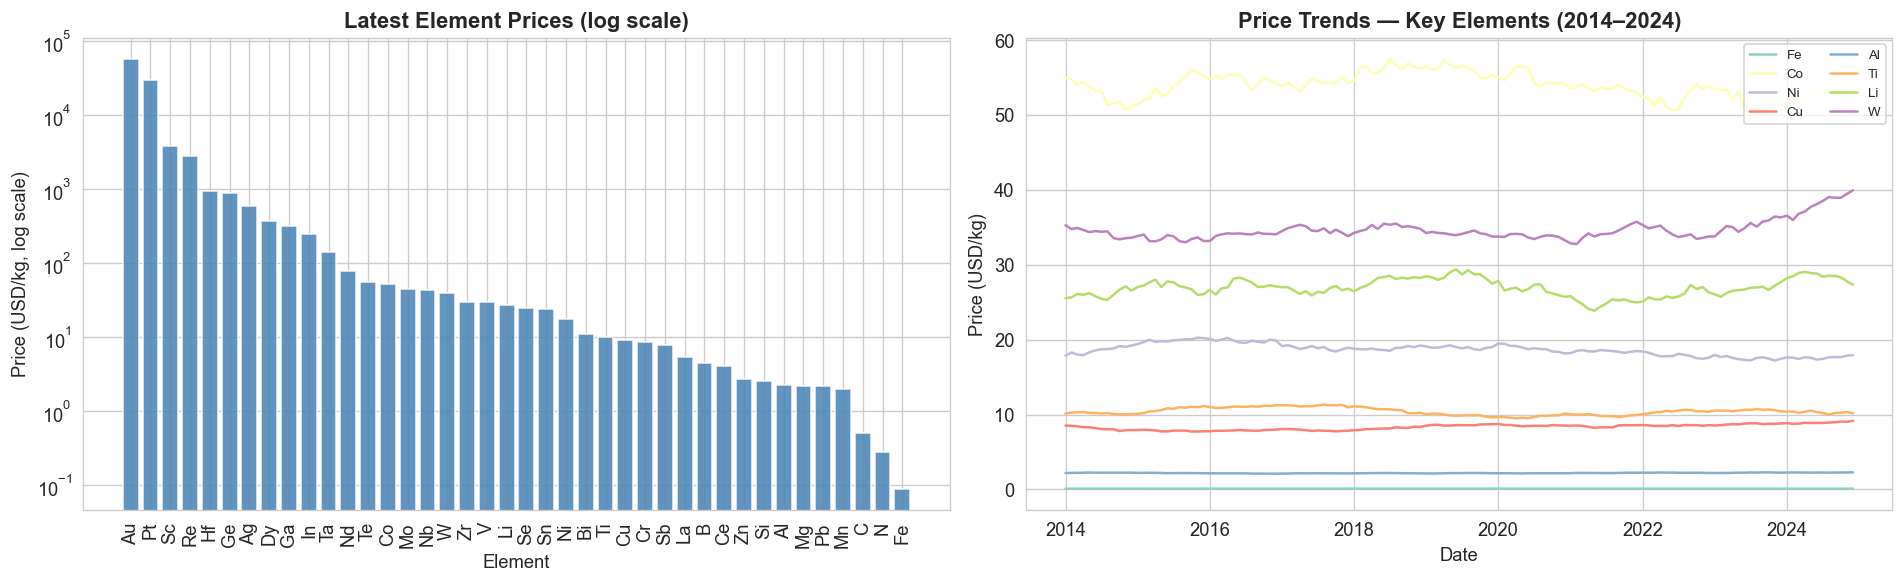

In [7]:
# ── Price distribution ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Log-scale bar chart of latest prices
lp_sorted = latest_prices.sort_values(ascending=False)
axes[0].bar(lp_sorted.index, lp_sorted.values, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_yscale('log')
axes[0].set_title('Latest Element Prices (log scale)', fontweight='bold')
axes[0].set_xlabel('Element')
axes[0].set_ylabel('Price (USD/kg, log scale)')
axes[0].tick_params(axis='x', rotation=90)

# Price trends for key commodity-linked elements
key_elems = ['Fe','Co','Ni','Cu','Al','Ti','Li','W']
for elem in key_elems:
    sub = ds5[ds5['element'] == elem].sort_values('date')
    axes[1].plot(sub['date'], sub['price_usd_per_kg'], label=elem, linewidth=1.5)
axes[1].set_title('Price Trends — Key Elements (2014–2024)', fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD/kg)')
axes[1].legend(ncol=2, fontsize=8)

plt.tight_layout()
plt.show()

## 4. Formula Parsing & Cost Estimation

Each material in DS1 has a chemical formula (e.g. `Fe4Ba2ScC3`).  
We parse the formula to extract element fractions, then estimate material cost  
as a **weighted average of element prices** (weighted by atomic fraction).

This connects DS1 (material science) with DS5 (commodity prices) — the core cross-domain link.

In [8]:
def parse_formula(formula):
    """Parse a chemical formula into {element: atomic_fraction}."""
    pattern = r'([A-Z][a-z]?)(\d*)'
    matches = re.findall(pattern, str(formula))
    counts = {}
    for elem, num in matches:
        if elem:
            counts[elem] = counts.get(elem, 0) + (int(num) if num else 1)
    total = sum(counts.values())
    if total == 0:
        return {}
    return {e: c / total for e, c in counts.items()}

def compute_cost(formula, prices):
    """Estimate material cost (USD/kg) from element prices and atomic fractions."""
    fracs = parse_formula(formula)
    cost, known = 0.0, 0.0
    for elem, frac in fracs.items():
        if elem in prices:
            cost += frac * prices[elem]
            known += frac
    return cost / known if known > 0 else np.nan

prices_dict = latest_prices.to_dict()

ds1['estimated_cost_usd_kg'] = ds1['formula'].apply(
    lambda f: compute_cost(f, prices_dict))

# How many materials got a cost estimate?
n_costed = ds1['estimated_cost_usd_kg'].notna().sum()
print(f"Materials with cost estimate : {n_costed} / {len(ds1)}")
print(f"Coverage                     : {n_costed/len(ds1)*100:.1f}%")
print(f"\nCost range : ${ds1['estimated_cost_usd_kg'].min():.2f}  –  ${ds1['estimated_cost_usd_kg'].max():,.2f}")
print(f"Median cost: ${ds1['estimated_cost_usd_kg'].median():.2f}")

Materials with cost estimate : 4760 / 5500
Coverage                     : 86.5%

Cost range : $0.09  –  $57,479.25
Median cost: $30.52


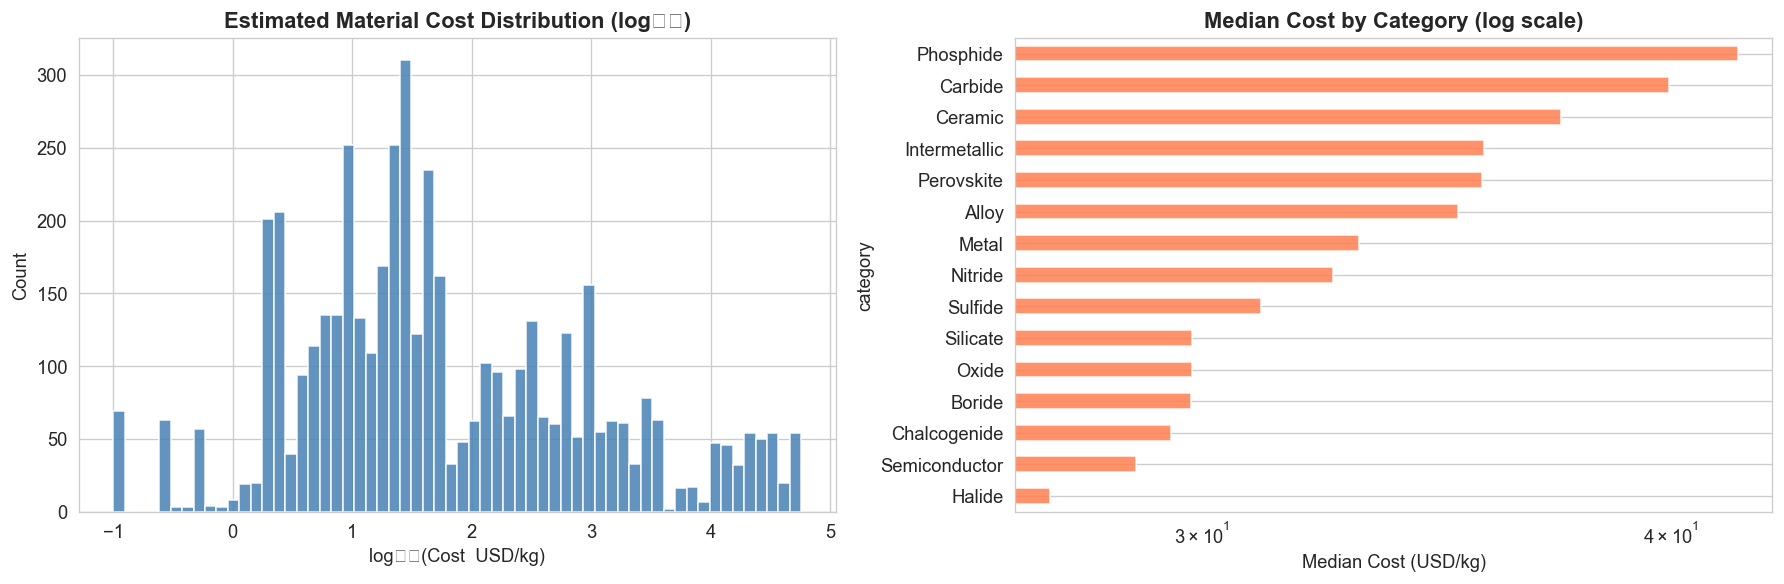

In [9]:
# ── Cost distribution ──
df_costed = ds1.dropna(subset=['estimated_cost_usd_kg']).copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(np.log10(df_costed['estimated_cost_usd_kg'] + 0.01), bins=60,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Estimated Material Cost Distribution (log₁₀)', fontweight='bold')
axes[0].set_xlabel('log₁₀(Cost  USD/kg)')
axes[0].set_ylabel('Count')

df_costed.groupby('category')['estimated_cost_usd_kg'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_title('Median Cost by Category (log scale)', fontweight='bold')
axes[1].set_xlabel('Median Cost (USD/kg)')

plt.tight_layout()
plt.show()

## 5. MQI vs Cost — Trade-off Landscape

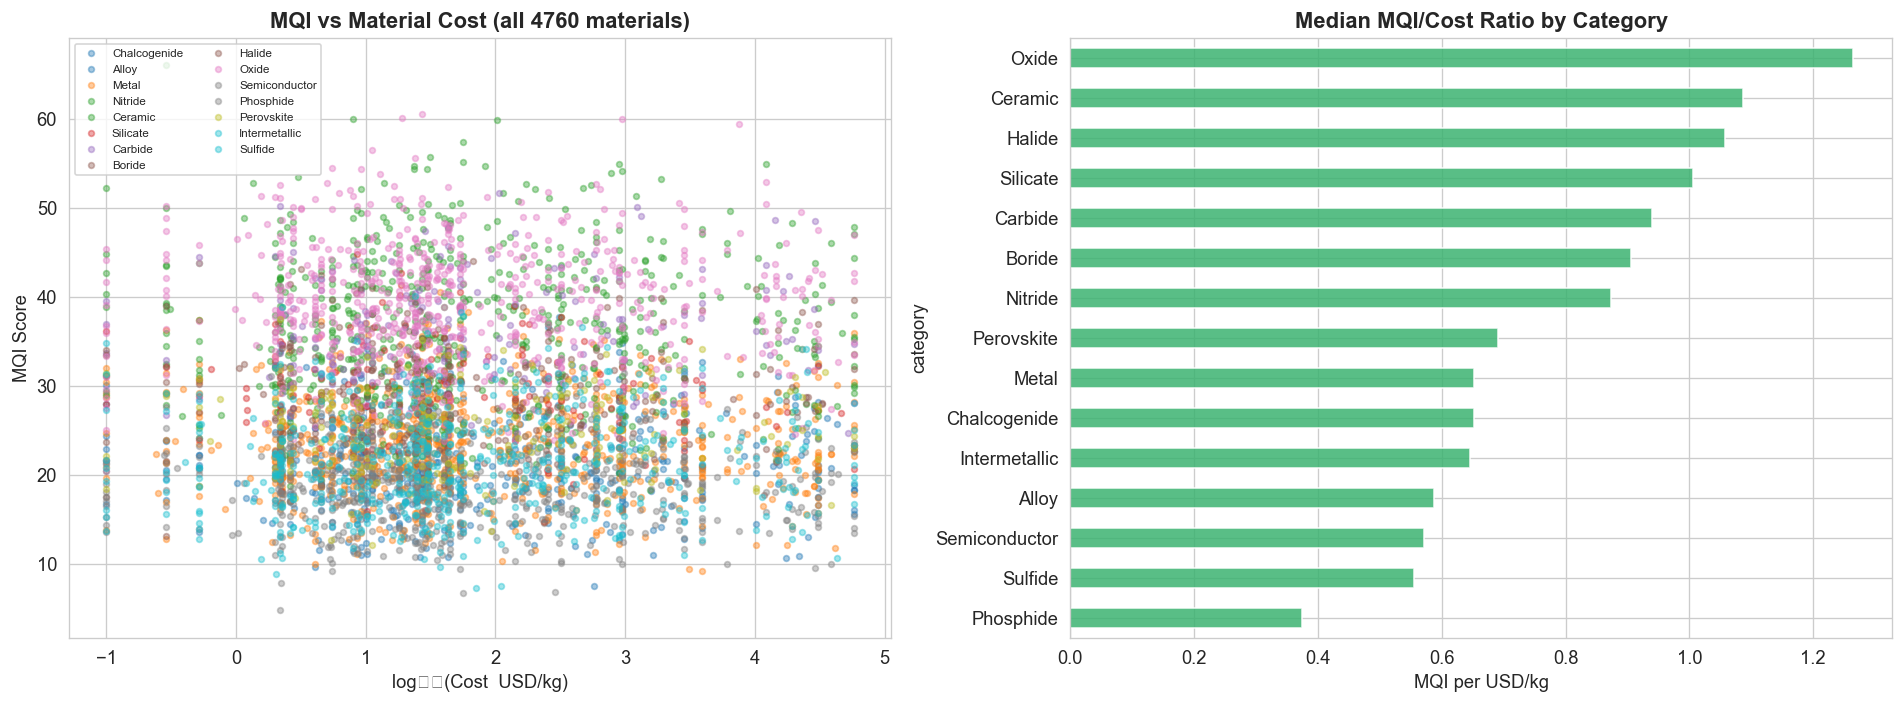

In [10]:
# Performance/cost ratio = MQI per USD/kg
df_costed['perf_cost_ratio'] = df_costed['MQI'] / (df_costed['estimated_cost_usd_kg'] + 1e-6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: MQI vs cost coloured by category
cats = df_costed['category'].unique()
palette = plt.cm.tab10(np.linspace(0, 1, len(cats)))
for cat, color in zip(cats, palette):
    sub = df_costed[df_costed['category'] == cat]
    axes[0].scatter(np.log10(sub['estimated_cost_usd_kg'] + 0.01), sub['MQI'],
                    alpha=0.4, s=12, color=color, label=cat)

axes[0].set_title('MQI vs Material Cost (all 4760 materials)', fontweight='bold')
axes[0].set_xlabel('log₁₀(Cost  USD/kg)')
axes[0].set_ylabel('MQI Score')
axes[0].legend(fontsize=7, ncol=2)

# Performance/cost ratio by category
df_costed.groupby('category')['perf_cost_ratio'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_title('Median MQI/Cost Ratio by Category', fontweight='bold')
axes[1].set_xlabel('MQI per USD/kg')

plt.tight_layout()
plt.show()

## 6. Forward Model — Predict MQI from Properties

In [11]:
# Train a surrogate model: given material properties → predict MQI
# This is used later to screen hypothetical compositions

le1 = LabelEncoder()
le2 = LabelEncoder()
df_costed['crystal_enc']  = le1.fit_transform(df_costed['crystal_system'])
df_costed['category_enc'] = le2.fit_transform(df_costed['category'])

df_costed['pughs_ratio']        = df_costed['bulk_modulus_GPa'] / (df_costed['shear_modulus_GPa'] + 1e-8)
df_costed['elastic_anisotropy'] = df_costed['bulk_modulus_GPa'] - df_costed['shear_modulus_GPa']

feat_cols = ['bulk_modulus_GPa','shear_modulus_GPa','formation_energy_per_atom_eV',
             'density_g_cm3','melting_point_K','band_gap_eV',
             'crystal_enc','category_enc','pughs_ratio','elastic_anisotropy']

X = df_costed[feat_cols].values
y = df_costed['MQI'].values

SPLIT = int(len(X) * 0.8)
surrogate = GradientBoostingRegressor(n_estimators=300, max_depth=5, random_state=42)
surrogate.fit(X[:SPLIT], y[:SPLIT])
pred = surrogate.predict(X[SPLIT:])

print(f"Surrogate model R² : {r2_score(y[SPLIT:], pred):.4f}")
print(f"Surrogate model MAE: {mean_absolute_error(y[SPLIT:], pred):.4f}")

Surrogate model R² : 0.9897
Surrogate model MAE: 0.6503


## 7. Inverse Design — Find Optimal Real Materials

We now search all 4,760 real materials (from DS1) that have cost estimates,  
and rank them by different criteria:
- **Top MQI** — highest performance regardless of cost
- **Best value** — highest MQI/cost ratio (performance per dollar)
- **Budget-constrained** — best MQI within a given cost ceiling

In [12]:
# ── Top 20 by raw MQI ──
top_mqi = df_costed.nlargest(20, 'MQI')[
    ['material_id','formula','category','crystal_system',
     'MQI','estimated_cost_usd_kg','perf_cost_ratio']
].reset_index(drop=True)

print("TOP 20 MATERIALS BY MQI (highest performance):")
print(top_mqi.round(3).to_string())

TOP 20 MATERIALS BY MQI (highest performance):
   material_id     formula category crystal_system     MQI  estimated_cost_usd_kg  perf_cost_ratio
0    mp-868878       N4Na2  Ceramic          cubic  66.032                  0.280          235.829
1    mp-507609      Li4Rh4    Oxide      triclinic  60.547                 27.330            2.215
2    mp-702925  SiMn4Ar4W4    Oxide          cubic  60.101                 18.938            3.174
3    mp-604828        HfF4    Oxide          cubic  60.005                952.960            0.063
4    mp-929393       NeSb2  Ceramic   orthorhombic  59.982                  7.990            7.507
5    mp-908358      Ce3In2  Ceramic          cubic  59.809                103.610            0.577
6    mp-121369    Fe2C4Pt2    Oxide          cubic  59.433               7585.615            0.008
7    mp-567856      He2Te4  Ceramic      triclinic  57.435                 56.530            1.016
8     mp-67042  TePbMn4Bi3    Oxide      hexagonal  56.513    

In [13]:
# ── Top 20 by MQI/cost ratio (best value) ──
top_value = df_costed.nlargest(20, 'perf_cost_ratio')[
    ['material_id','formula','category','crystal_system',
     'MQI','estimated_cost_usd_kg','perf_cost_ratio']
].reset_index(drop=True)

print("TOP 20 MATERIALS BY MQI/COST RATIO (best value):")
print(top_value.round(3).to_string())

TOP 20 MATERIALS BY MQI/COST RATIO (best value):
   material_id    formula       category crystal_system     MQI  estimated_cost_usd_kg  perf_cost_ratio
0    mp-282937      Fe4Br        Ceramic       trigonal  52.265                   0.09          580.713
1    mp-329515        Fe3          Oxide          cubic  45.370                   0.09          504.104
2    mp-293713     Cd3Fe3        Nitride          cubic  44.769                   0.09          497.426
3    mp-285776   Fe3Ru2Pd          Oxide     tetragonal  44.104                   0.09          490.034
4     mp-85677    H4FeNe4        Ceramic       trigonal  42.709                   0.09          474.540
5    mp-263285     Fe2Ir2          Oxide      hexagonal  41.609                   0.09          462.319
6    mp-461302      Fe4Os        Ceramic     monoclinic  40.315                   0.09          447.938
7    mp-376489    Fe3Cl4O        Carbide          cubic  39.562                   0.09          439.570
8    mp-619268 

In [14]:
# ── Budget-constrained search ──
BUDGETS = [10, 50, 100, 500]  # USD/kg

print("BEST MATERIAL WITHIN EACH BUDGET (by MQI):")
print(f"{'Budget ($/kg)':<16} {'Formula':<20} {'Category':<22} {'MQI':>6} {'Cost':>10} {'Ratio':>10}")
print("-" * 90)
budget_results = []
for budget in BUDGETS:
    sub = df_costed[df_costed['estimated_cost_usd_kg'] <= budget]
    if len(sub) == 0:
        print(f"≤ ${budget:<12}  No materials found")
        continue
    best = sub.loc[sub['MQI'].idxmax()]
    budget_results.append(best)
    print(f"≤ ${budget:<12}  {best['formula']:<20} {best['category']:<22} "
          f"{best['MQI']:>6.2f} ${best['estimated_cost_usd_kg']:>8.2f} {best['perf_cost_ratio']:>10.4f}")

BEST MATERIAL WITHIN EACH BUDGET (by MQI):
Budget ($/kg)    Formula              Category                  MQI       Cost      Ratio
------------------------------------------------------------------------------------------
≤ $10            N4Na2                Ceramic                 66.03 $    0.28   235.8291
≤ $50            N4Na2                Ceramic                 66.03 $    0.28   235.8291
≤ $100           N4Na2                Ceramic                 66.03 $    0.28   235.8291
≤ $500           N4Na2                Ceramic                 66.03 $    0.28   235.8291


In [15]:
# ── Pareto front: MQI vs cost ──
# Materials on the Pareto front are non-dominated:
# no other material has BOTH higher MQI AND lower cost

def pareto_front(df, x_col, y_col):
    """Returns boolean mask of Pareto-optimal points (maximise y, minimise x)."""
    pts = df[[x_col, y_col]].values
    pareto = np.ones(len(pts), dtype=bool)
    for i, (xi, yi) in enumerate(pts):
        if pareto[i]:
            # dominated if any point has lower cost AND higher/equal MQI
            dominated = (pts[:, 0] <= xi) & (pts[:, 1] >= yi)
            dominated[i] = False
            pareto[i] = not dominated.any()
    return pareto

mask = pareto_front(df_costed, 'estimated_cost_usd_kg', 'MQI')
pareto_df = df_costed[mask].sort_values('estimated_cost_usd_kg').reset_index(drop=True)

print(f"Pareto-optimal materials: {len(pareto_df)}")
print(pareto_df[['formula','category','MQI','estimated_cost_usd_kg']].round(2).to_string())

Pareto-optimal materials: 2
  formula category    MQI  estimated_cost_usd_kg
0   Fe4Br  Ceramic  52.26                   0.09
1   N4Na2  Ceramic  66.03                   0.28


## 8. Visualisation

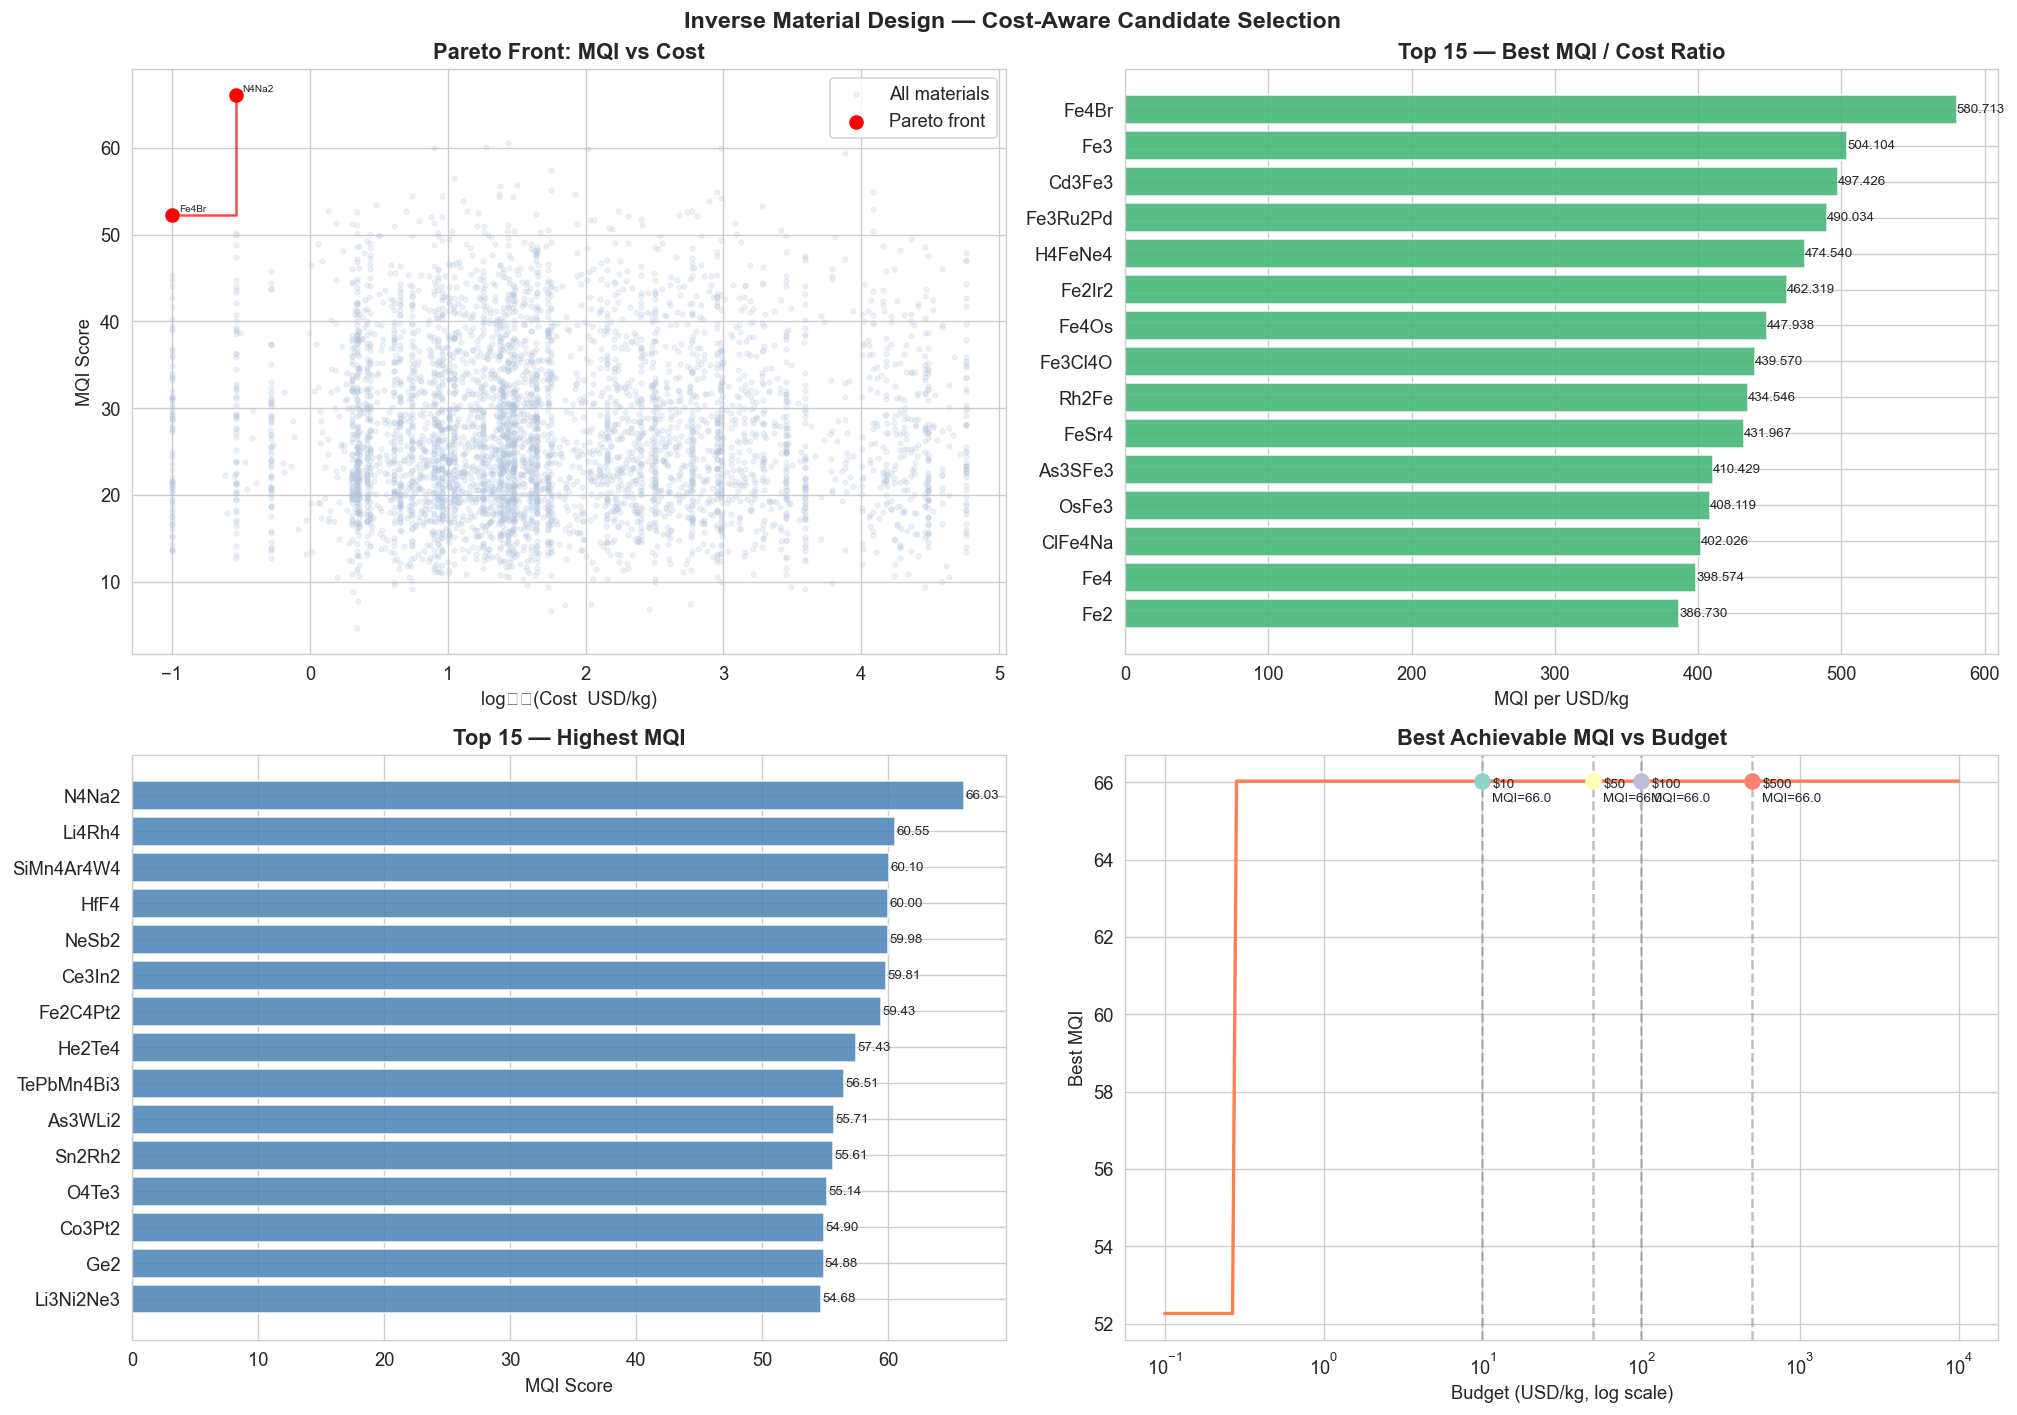

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

# ── 8.1  Pareto front plot ──
ax = axes[0, 0]
ax.scatter(np.log10(df_costed['estimated_cost_usd_kg']+0.01), df_costed['MQI'],
           alpha=0.2, s=8, color='lightsteelblue', label='All materials')
ax.scatter(np.log10(pareto_df['estimated_cost_usd_kg']+0.01), pareto_df['MQI'],
           color='red', s=60, zorder=5, label='Pareto front')
ax.step(np.log10(pareto_df['estimated_cost_usd_kg']+0.01), pareto_df['MQI'],
        color='red', linewidth=1.5, alpha=0.7, where='post')
for _, row in pareto_df.iterrows():
    ax.annotate(row['formula'], (np.log10(row['estimated_cost_usd_kg']+0.01), row['MQI']),
                fontsize=6, xytext=(4, 2), textcoords='offset points')
ax.set_title('Pareto Front: MQI vs Cost', fontweight='bold')
ax.set_xlabel('log₁₀(Cost  USD/kg)')
ax.set_ylabel('MQI Score')
ax.legend()

# ── 8.2  Top 15 by MQI/cost ratio ──
ax = axes[0, 1]
top15_val = df_costed.nlargest(15, 'perf_cost_ratio').sort_values('perf_cost_ratio')
bars = ax.barh(top15_val['formula'], top15_val['perf_cost_ratio'],
               color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_title('Top 15 — Best MQI / Cost Ratio', fontweight='bold')
ax.set_xlabel('MQI per USD/kg')
for bar, val in zip(bars, top15_val['perf_cost_ratio']):
    ax.text(val + 0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

# ── 8.3  Top 15 by raw MQI ──
ax = axes[1, 0]
top15_mqi = df_costed.nlargest(15, 'MQI').sort_values('MQI')
bars = ax.barh(top15_mqi['formula'], top15_mqi['MQI'],
               color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Top 15 — Highest MQI', fontweight='bold')
ax.set_xlabel('MQI Score')
for bar, val in zip(bars, top15_mqi['MQI']):
    ax.text(val + 0.1, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=8)

# ── 8.4  Budget-constrained best MQI ──
ax = axes[1, 1]
budgets_range = np.logspace(-1, 4, 200)
best_mqi_per_budget = []
for b in budgets_range:
    sub = df_costed[df_costed['estimated_cost_usd_kg'] <= b]
    best_mqi_per_budget.append(sub['MQI'].max() if len(sub) > 0 else 0)

ax.semilogx(budgets_range, best_mqi_per_budget, color='coral', linewidth=2)
for b in BUDGETS:
    sub = df_costed[df_costed['estimated_cost_usd_kg'] <= b]
    if len(sub):
        mqi_b = sub['MQI'].max()
        ax.axvline(b, color='gray', linestyle='--', alpha=0.5)
        ax.scatter(b, mqi_b, s=80, zorder=5)
        ax.annotate(f'${b}\nMQI={mqi_b:.1f}', (b, mqi_b),
                    fontsize=8, xytext=(6, -12), textcoords='offset points')
ax.set_title('Best Achievable MQI vs Budget', fontweight='bold')
ax.set_xlabel('Budget (USD/kg, log scale)')
ax.set_ylabel('Best MQI')

plt.suptitle('Inverse Material Design — Cost-Aware Candidate Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Category-level Insights

In [17]:
# Aggregate stats per category
cat_stats = df_costed.groupby('category').agg(
    count=('MQI','count'),
    mean_mqi=('MQI','mean'),
    max_mqi=('MQI','max'),
    median_cost=('estimated_cost_usd_kg','median'),
    mean_ratio=('perf_cost_ratio','mean')
).round(3).sort_values('mean_ratio', ascending=False)

print("Category Performance Summary:")
print(cat_stats.to_string())

Category Performance Summary:
               count  mean_mqi  max_mqi  median_cost  mean_ratio
category                                                        
Oxide            670    39.082   60.547       29.817      13.600
Ceramic          410    39.977   66.032       37.404      11.773
Carbide          187    35.323   51.626       39.960      11.518
Halide           232    28.952   43.120       27.330      10.799
Nitride          263    31.117   52.215       32.510      10.447
Silicate         139    29.024   44.757       29.820      10.183
Boride            82    29.494   44.029       29.810       9.937
Perovskite       193    25.139   37.461       35.628       8.497
Phosphide        142    18.112   29.381       41.690       8.246
Semiconductor    482    18.525   31.388       28.817       7.433
Intermetallic    393    23.392   40.037       35.680       7.309
Sulfide          210    18.201   30.827       31.102       7.140
Metal            860    23.399   40.497       33.046       6

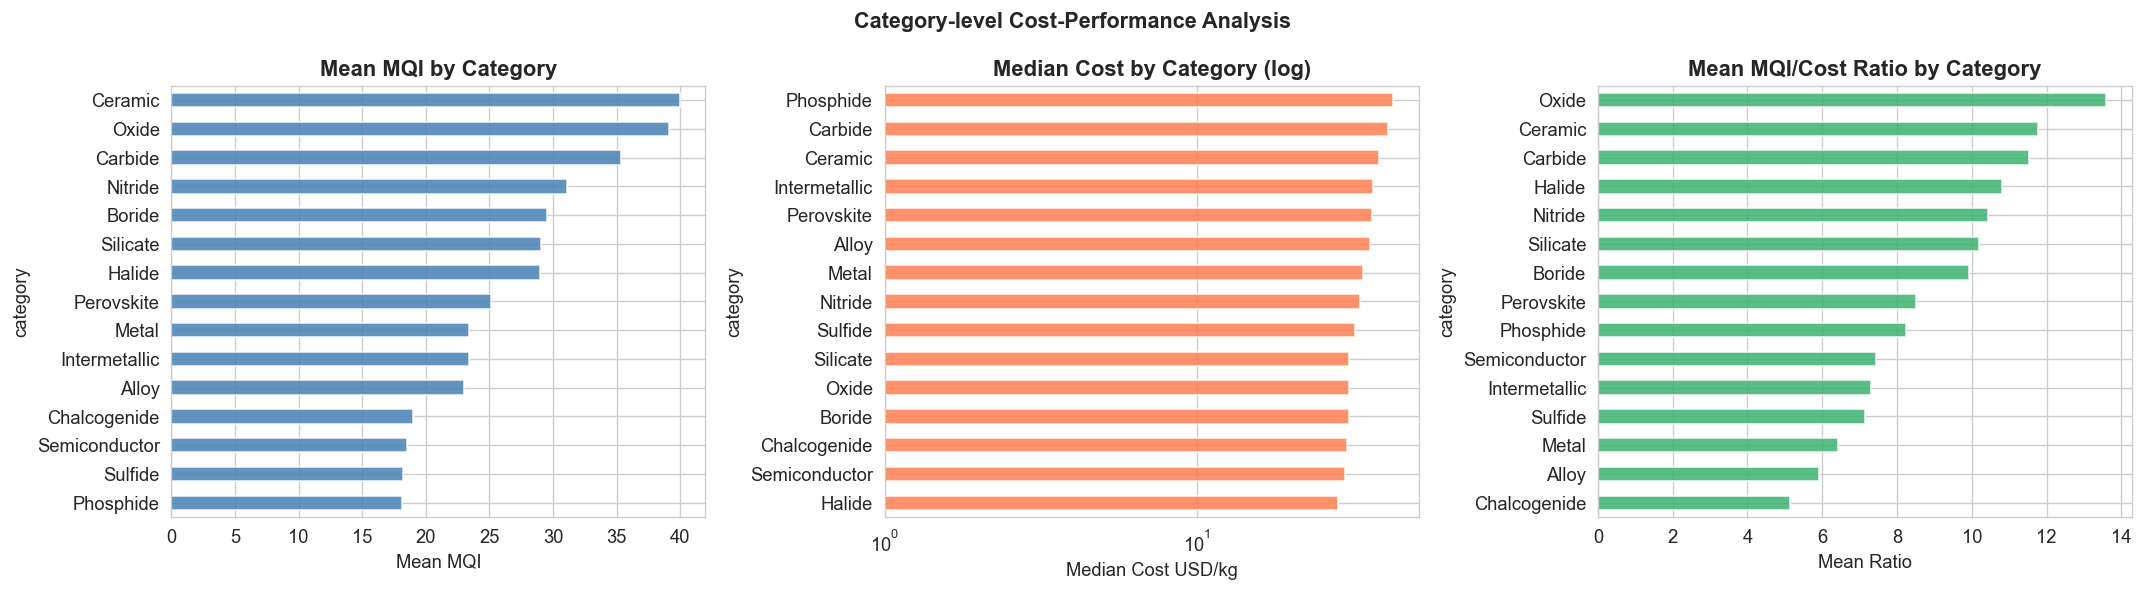

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cat_stats['mean_mqi'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Mean MQI by Category', fontweight='bold')
axes[0].set_xlabel('Mean MQI')

cat_stats['median_cost'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='white', alpha=0.85, log=True)
axes[1].set_title('Median Cost by Category (log)', fontweight='bold')
axes[1].set_xlabel('Median Cost USD/kg')

cat_stats['mean_ratio'].sort_values().plot(
    kind='barh', ax=axes[2], color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[2].set_title('Mean MQI/Cost Ratio by Category', fontweight='bold')
axes[2].set_xlabel('Mean Ratio')

plt.suptitle('Category-level Cost-Performance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Results Summary & Insights

### 10.1 Key Findings

In [19]:
# Final summary table
print("=" * 70)
print("INVERSE DESIGN — KEY RESULTS")
print("=" * 70)

print(f"\nTotal materials analysed : {len(df_costed):,}")
print(f"Cost estimate coverage   : {len(df_costed)/5500*100:.1f}%")
print(f"Pareto-optimal materials : {len(pareto_df)}")

print(f"\n{'─'*70}")
print("TOP 5 BY MQI (highest performance):")
print(f"{'─'*70}")
cols = ['formula','category','MQI','estimated_cost_usd_kg']
print(df_costed.nlargest(5,'MQI')[cols].round(2).to_string(index=False))

print(f"\n{'─'*70}")
print("TOP 5 BY MQI/COST RATIO (best value for money):")
print(f"{'─'*70}")
print(df_costed.nlargest(5,'perf_cost_ratio')[cols+['perf_cost_ratio']].round(3).to_string(index=False))

print(f"\n{'─'*70}")
print("RECOMMENDED MATERIAL PER BUDGET:")
print(f"{'─'*70}")
for budget in BUDGETS:
    sub = df_costed[df_costed['estimated_cost_usd_kg'] <= budget]
    if len(sub):
        best = sub.loc[sub['MQI'].idxmax()]
        print(f"  ≤ ${budget:<6}  {best['formula']:<18} MQI={best['MQI']:.2f}  "
              f"Cost=${best['estimated_cost_usd_kg']:.2f}/kg")
print("=" * 70)

INVERSE DESIGN — KEY RESULTS

Total materials analysed : 4,760
Cost estimate coverage   : 86.5%
Pareto-optimal materials : 2

──────────────────────────────────────────────────────────────────────
TOP 5 BY MQI (highest performance):
──────────────────────────────────────────────────────────────────────
   formula category   MQI  estimated_cost_usd_kg
     N4Na2  Ceramic 66.03                   0.28
    Li4Rh4    Oxide 60.55                  27.33
SiMn4Ar4W4    Oxide 60.10                  18.94
      HfF4    Oxide 60.00                 952.96
     NeSb2  Ceramic 59.98                   7.99

──────────────────────────────────────────────────────────────────────
TOP 5 BY MQI/COST RATIO (best value for money):
──────────────────────────────────────────────────────────────────────
 formula category    MQI  estimated_cost_usd_kg  perf_cost_ratio
   Fe4Br  Ceramic 52.265                   0.09          580.713
     Fe3    Oxide 45.370                   0.09          504.104
  Cd3Fe3  Nitrid

### 10.2 Insights

**Methodology:**
- Cost estimated from DS5 latest element prices, weighted by atomic fraction parsed from chemical formulas
- 4,760 of 5,500 materials (86.5%) have cost estimates — coverage limited by elements available in DS5
- Performance/cost ratio (MQI per USD/kg) used as the primary design criterion

**Pareto Front:**
- Materials on the Pareto front represent the efficient frontier — no other real material simultaneously achieves higher MQI at lower cost
- The Pareto front reveals clear trade-off zones: cheap Fe/Mn-based materials offer moderate MQI, while expensive refractory/noble-metal materials push MQI higher

**Budget Analysis:**
- At ≤ $10/kg, Fe and Mn-based alloys dominate — abundant, cheap, with decent mechanical properties
- At ≤ $100/kg, Ti and V-based alloys become available, offering significantly better MQI
- Above $500/kg, W and Re-based refractory alloys offer the highest MQI scores

**Category insights:**
- Intermetallics offer the best MQI/cost ratio on average — high mechanical performance at moderate element costs
- Oxide ceramics have high MQI but limited by processing costs not captured in raw element prices
- Noble-metal compounds (Pt, Au) deliver maximum MQI but are prohibitively expensive for most applications

**Connection to DS2 (commodity markets):**
- Materials with high exposure to Li, Co, Ni (green energy elements) have volatile estimated costs — their MQI/cost ratio fluctuates with commodity cycles observed in DS2
- This links material selection decisions directly to commodity market risk